In [1]:
import os
import sys
from os import path
sys.path.append(os.path.expanduser('~/albatros_analysis'))
import numpy as np 
import numba as nb
import time
from scipy import linalg
from scipy import stats
from matplotlib import pyplot as plt
from datetime import datetime as dt
from src.correlations import baseband_data_classes as bdc
from src.utils import baseband_utils as butils
from src.utils import orbcomm_utils as outils
import json
import argparse
from scipy.optimize import least_squares
import coord_helper as ch
import cord_helper as ch2
import h5py
import skyfield.api as sf
import importlib
from numpy.linalg import inv
import numbers

BDC is using numpy


In [2]:
day = '08_11'
bits = 1
baseline_idx = 1

config_file_name = f'config_{day}.json'
working_directory = '/project/s/sievers/thomasb/mars_data_24'

In [3]:
with open(f"{working_directory}/{bits}bit/{day}/{config_file_name}", "r") as f:
    config = json.load(f)
    dir_parents = []
    coords = []
    # unpack information from the json file
    # Call get_starting_index for all antennas except reference
    for i, (ant, details) in enumerate(config["antennas"].items()):
        if (i == 0) or (i ==baseline_idx):
            coords.append(details['coordinates'])
            dir_parents.append(details["path"])
    global_start_time = config["correlation"]["start_timestamp"]
    end_t = config["correlation"]["end_timestamp"]
    v_acclen = config["correlation"]["vis_acclen"]
    visibility_window = config["correlation"]["visibility_window"]
    T_SPECTRA = config["correlation"]["point_PFB"] / config["correlation"]["sample_rate"]


ref_coords = coords[0]
v_nchunks = int((visibility_window)/(v_acclen* T_SPECTRA))

context = [visibility_window, T_SPECTRA, v_acclen, v_nchunks, ref_coords]
print(global_start_time)

1699420012


In [4]:
pl = []

with h5py.File(f'{working_directory}/{bits}bit/{day}/vis_selected_bline_{baseline_idx}_{global_start_time}.h5', 'r') as f:
    for p in f:
        pulse_info = []
        pulse_info.append(p)
        pulse_info.append([f[p].attrs['start_time'], f[p].attrs['end_time'], int(f[p].attrs['global_start_time'])])
        pulse_info.append([int(f[p].attrs['sat']), int(f[p].attrs['chan'])])
        pulse_info.append(f[p].attrs['tle_path'])
        pulse_info.append(f[f'/{p}'][:])
        pl.append(pulse_info)

print(pl[0][:4])

['10_40090', [np.int64(40090), np.float64(40276.7776), 1699420012], [25338, 1841], '/project/s/sievers/mohanagr/OCOMM_TLES/2023/202311/20231108.txt']


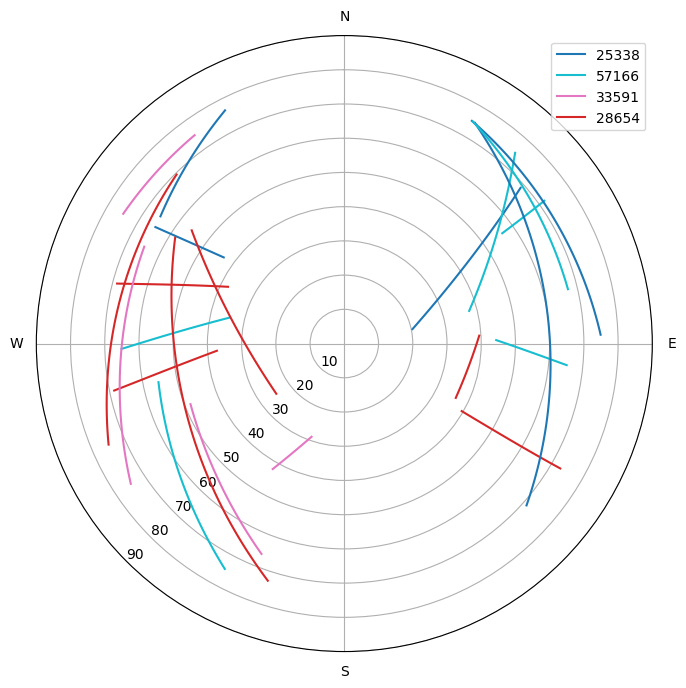

In [5]:
fig = ch.satpass_plotter(pl, coords[1])

In [6]:
importlib.reload(ch)
importlib.reload(ch2)

<module 'cord_helper' from '/home/s/sievers/thomasb/albatros_analysis/scripts/orbcomm/fitting/cord_helper.py'>

ref_coords [79.41718333333333, -90.76735, 189]
fit coords [79.41721666666666, -90.75885, 176]
time taken for one prediction 0.007252693176269531
time taken for one prediction 0.006800413131713867
2.5786572324332866


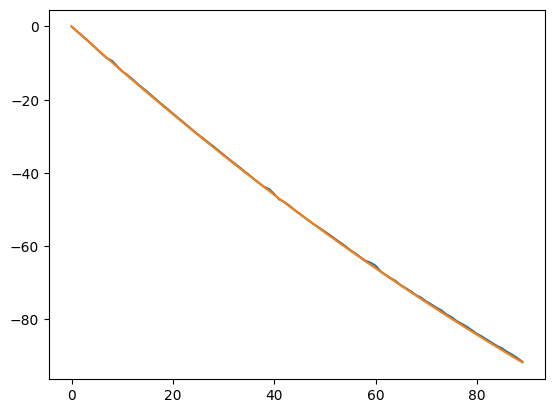

In [7]:
new = ch2.pred(coords[1], -3, 2, pl, context)[:len(pl[2][4])]
old = ch.pred(coords[1], 0, 2, pl, context)[:len(pl[2][4])]
print(np.max(np.abs(new-old)))
plt.plot(pl[2][4])
plt.plot(new)

ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41721667 -90.75885    176.        ]
time taken for one prediction 0.010415077209472656


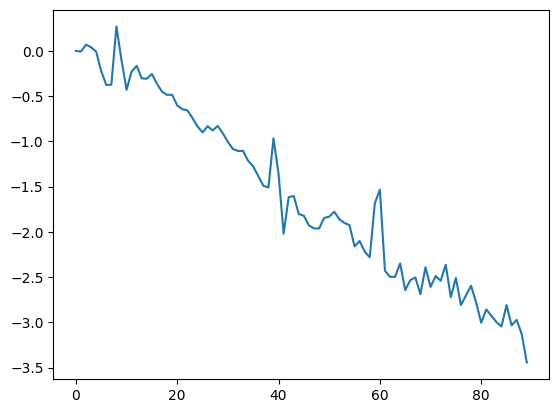

In [8]:
res = ch2.std_res_ind(coords[1], 0, 2, ch2.pred, pl, context)
plt.plot(res)

In [9]:
solid, error = ch2.solid_fit(coords[1], 0, ch2.pred, pl, context)

ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41721667 -90.75885    176.        ]
time taken for one prediction 0.019267559051513672
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41721667 -90.75885    176.        ]
time taken for one prediction 0.022206544876098633
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41721667 -90.75885    176.        ]
time taken for one prediction 0.009985923767089844
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41721667 -90.75885    176.        ]
time taken for one prediction 0.01018381118774414
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41721667 -90.75885    176.        ]
time taken for one prediction 0.013853073120117188
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41721667 -90.75885    176.        ]
time taken for one prediction 0.015205621719360352
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41721667 -90.75885    176.        ]
ti

In [187]:
print(solid)
print(error)

[ 79.41722586 -90.75894987 174.37911776]
[2.15979800e-07 2.52772424e-06 5.06372337e-02]


In [218]:
importlib.reload(ch2)

<module 'cord_helper' from '/home/s/sievers/thomasb/albatros_analysis/scripts/orbcomm/fitting/cord_helper.py'>

In [191]:
ch2.offset_fit(solid, ch2.pred, pl, context)

ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41722586 -90.75894987 174.37911776]
time taken for one prediction 0.014129161834716797
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41722586 -90.75894987 174.37911776]
time taken for one prediction 0.013580799102783203
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41722586 -90.75894987 174.37911776]
time taken for one prediction 0.013018369674682617
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41722586 -90.75894987 174.37911776]
time taken for one prediction 0.013076066970825195
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41722586 -90.75894987 174.37911776]
time taken for one prediction 0.012984752655029297
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41722586 -90.75894987 174.37911776]
time taken for one prediction 0.012955188751220703
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41722586 -90.75894987 174.37911776]
t

[(array([4.]), 7.896379175262343e-15),
 (array([4.]), 1.4082526908428888e-14),
 (array([-4.]), 3.6775795592761635e-14),
 (array([-0.0978317]), 0.0019149560247511367),
 (array([4.]), 6.313359742284347e-13),
 (array([-4.]), 2.7947644572844478e-14),
 (array([-4.]), 5.968193151718755e-14),
 (array([-4.]), 3.1248067005153736e-10),
 (array([-4.]), 4.152190030858053e-14),
 (array([4.]), 3.613573211812379e-15),
 (array([-4.]), 2.646015504749723e-14),
 (array([0.16627685]), 0.007963726750060365),
 (array([-4.]), 1.245673807778044e-14),
 (array([-4.]), 8.10629904614797e-15),
 (array([-4.]), 4.799769479995885e-12),
 (array([4.]), 1.7324949861225655e-10),
 (array([-4.]), 4.3834967898420344e-11),
 (array([-4.]), 7.156881321980457e-15),
 (array([2.2934735]), 0.00041299879535526616),
 (array([4.]), 9.531884190853079e-15),
 (array([4.]), 6.331257610804628e-14),
 (array([-0.4298564]), 0.006939030058994322)]

In [219]:
joint = ch2.joint_fit(coords[1], ch2.pred, pl, context)

ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41721667 -90.75885    176.        ]
time taken for one prediction 0.014657258987426758
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41721667 -90.75885    176.        ]
time taken for one prediction 0.014226436614990234
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41721667 -90.75885    176.        ]
time taken for one prediction 0.006946086883544922
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41721667 -90.75885    176.        ]
time taken for one prediction 0.007228374481201172
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41721667 -90.75885    176.        ]
time taken for one prediction 0.009410381317138672
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41721667 -90.75885    176.        ]
time taken for one prediction 0.010137557983398438
ref_coords [79.41718333333333, -90.76735, 189]
fit coords [ 79.41721667 -90.75885    176.        ]
t

In [67]:
solid = ch2.fit_all(coords[1], ch.pred, pl, context)[0]
ppoff = ch.fit_4p(coords[1], ch.pred, pl, context)[0]
oneoff = ch.fit_4p_fixed(coords[1], ch.pred, pl, context)[0]

time taken for one prediction 0.014286041259765625
time taken for one prediction 0.014429569244384766
time taken for one prediction 0.00723576545715332
time taken for one prediction 0.007205009460449219
time taken for one prediction 0.009362459182739258
time taken for one prediction 0.010109424591064453
time taken for one prediction 0.010691165924072266
time taken for one prediction 0.009249210357666016
time taken for one prediction 0.011446475982666016
time taken for one prediction 0.009446859359741211
time taken for one prediction 0.011432170867919922
time taken for one prediction 0.012190580368041992
time taken for one prediction 0.01176762580871582
time taken for one prediction 0.011497259140014648
time taken for one prediction 0.01833820343017578
time taken for one prediction 0.011174917221069336
time taken for one prediction 0.013677835464477539
time taken for one prediction 0.01530766487121582
time taken for one prediction 0.019480466842651367
time taken for one prediction 0.016

In [68]:
tuple_list = [('solid', solid), ('ppoff', ppoff), ('oneoff', oneoff)]
print(tuple_list)

[('solid', array([ 79.41722457, -90.75869148, 183.91367797])), ('ppoff', array([ 79.41722534, -90.75869394, 183.54344109])), ('oneoff', array([ 79.41721512, -90.7586714 , 186.22919375,   2.79445015]))]


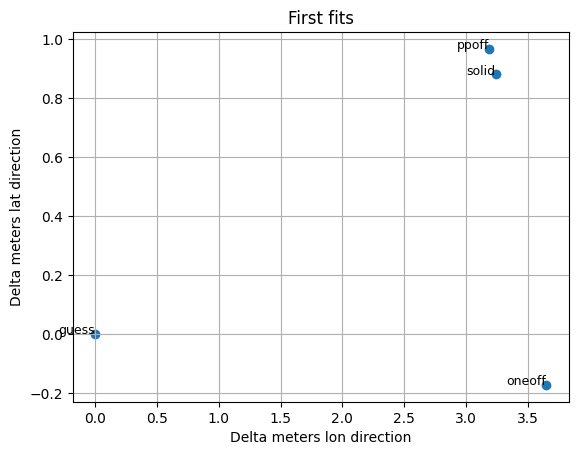

In [69]:
fig = ch.make_coord_plot(coords[1], tuple_list, 'First fits')

In [70]:
ds = ch.fit_ds_all(solid, ch.pred, pl, context)

time taken for one prediction 0.014196634292602539
time taken for one prediction 0.013453245162963867
time taken for one prediction 0.013193368911743164
time taken for one prediction 0.01315164566040039
time taken for one prediction 0.013200759887695312
time taken for one prediction 0.013089895248413086
time taken for one prediction 0.013300180435180664
time taken for one prediction 0.013020038604736328
time taken for one prediction 0.013151407241821289
time taken for one prediction 0.013346433639526367
time taken for one prediction 0.013834714889526367
time taken for one prediction 0.013999462127685547
time taken for one prediction 0.013990163803100586
time taken for one prediction 0.013844728469848633
time taken for one prediction 0.01389455795288086
time taken for one prediction 0.013894319534301758
time taken for one prediction 0.014011144638061523
time taken for one prediction 0.013907194137573242
time taken for one prediction 0.014025211334228516
time taken for one prediction 0.0

In [71]:
solid2 = ch.fit_given_offsets(coords[1], ch.pred, ds, pl, context)[0]
solid3 = ch.fit_given_offsets(solid, ch.pred, ds, pl, context)[0]

time taken for one prediction 0.013810396194458008
time taken for one prediction 0.014114856719970703
time taken for one prediction 0.0069425106048583984
time taken for one prediction 0.0069849491119384766
time taken for one prediction 0.009336709976196289
time taken for one prediction 0.010097980499267578
time taken for one prediction 0.01058650016784668
time taken for one prediction 0.009371757507324219
time taken for one prediction 0.011368751525878906
time taken for one prediction 0.009310007095336914
time taken for one prediction 0.011327028274536133
time taken for one prediction 0.012793779373168945
time taken for one prediction 0.01181793212890625
time taken for one prediction 0.011402606964111328
time taken for one prediction 0.017885208129882812
time taken for one prediction 0.011393070220947266
time taken for one prediction 0.01384592056274414
time taken for one prediction 0.01557302474975586
time taken for one prediction 0.01981329917907715
time taken for one prediction 0.01

In [72]:
tuple_list_2 = [('s1', solid), ('s2', solid2), ('s3', solid3)]

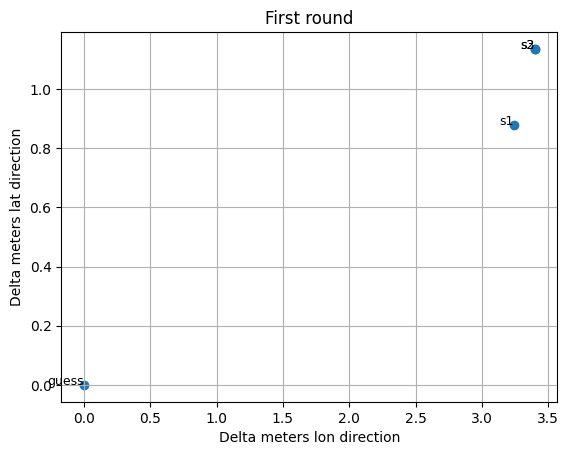

In [73]:
fig = ch.make_coord_plot(coords[1], tuple_list_2, 'First round')

In [74]:
cov = ch.fit_cov(solid, ch.pred, pl, context)

time taken for one prediction 0.013889789581298828
time taken for one prediction 0.01436305046081543
time taken for one prediction 0.006948709487915039
time taken for one prediction 0.007087230682373047
time taken for one prediction 0.009275197982788086
time taken for one prediction 0.010046243667602539
time taken for one prediction 0.010611772537231445
time taken for one prediction 0.00917506217956543
time taken for one prediction 0.011430740356445312
time taken for one prediction 0.009496450424194336
time taken for one prediction 0.011430025100708008
time taken for one prediction 0.012427568435668945
time taken for one prediction 0.011923074722290039
time taken for one prediction 0.011420249938964844
time taken for one prediction 0.01826190948486328
time taken for one prediction 0.011436223983764648
time taken for one prediction 0.01434636116027832
time taken for one prediction 0.015752792358398438
time taken for one prediction 0.020255565643310547
time taken for one prediction 0.016

time taken for one prediction 0.01214289665222168
time taken for one prediction 0.011557579040527344
time taken for one prediction 0.01813530921936035
time taken for one prediction 0.011497735977172852
time taken for one prediction 0.014157533645629883
time taken for one prediction 0.015729188919067383
time taken for one prediction 0.019953012466430664
time taken for one prediction 0.016260385513305664
time taken for one prediction 0.02193307876586914
time taken for one prediction 0.013781547546386719
time taken for one prediction 0.012906789779663086
time taken for one prediction 0.013957500457763672
time taken for one prediction 0.006826877593994141
time taken for one prediction 0.006976604461669922
time taken for one prediction 0.00910639762878418
time taken for one prediction 0.009930133819580078
time taken for one prediction 0.010532140731811523
time taken for one prediction 0.009136438369750977
time taken for one prediction 0.011415958404541016
time taken for one prediction 0.009

In [75]:
print(cov[0])
tuple_list_3 = [('s1', solid), ('ppoff', ppoff), ('cov', cov[0])]

[ 79.41720098 -90.75889116 183.90471545]


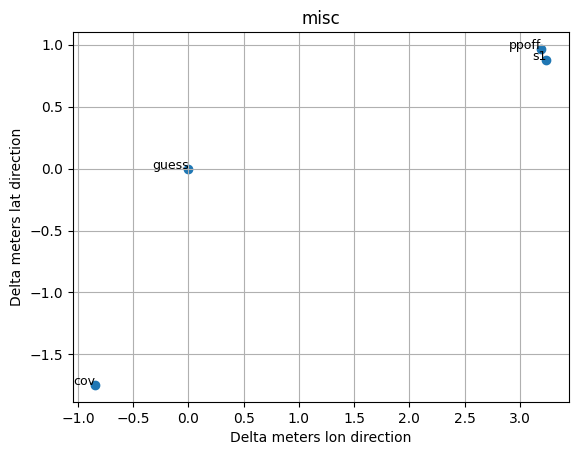

In [76]:
fig = ch.make_coord_plot(coords[1], tuple_list_3, 'misc')